 language_dynamics_extended_v5.py
  Configuration A: single-fit a=1.25 (1895-2020)
  Configuration B: dual-regime B1(a=1.478 / 1895-1970) + B2(a=0.655 / 1970-2020)
  J11 sign change at year 2007

TWO-SCENARIO COMPARISON  |  J00 decomposition for each scenario
  A: Single-fit a=1.25 (1895-2020)  |  B: Dual-regime B1(a=1.478) + B2(a=0.655)
Year     obs  xo*(A)   res(A)        regime_A    f'(A)       C00   |C|/|f'|    J00(A)  ||  xo*(B)   res(B)        regime_B    f'(B)    J00(B)
  --------------------------------------------------------------------------------------------------------------------------------
1895  0.2891   0.3807  +0.0916        A-Single   +0.0101   -0.0203      2.011   -0.0102  ||   0.3522  +0.0631    B1-Consensus   +0.0158   -0.0045  
1900  0.2948   0.3757  +0.0808        A-Single   +0.0103   -0.0201      1.950   -0.0098  ||   0.3387  +0.0438    B1-Consensus   +0.0162   -0.0039  
1910  0.2952   0.3632  +0.0680        A-Single   +0.0108   -0.0197      1.817   -0.0088  ||

/tmp/ipykernel_25249/139449357.py:847: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



  Saved: plots/lang_dyn_ext/timescale_comparison.jpg

All figures saved to plots/lang_dyn_ext/


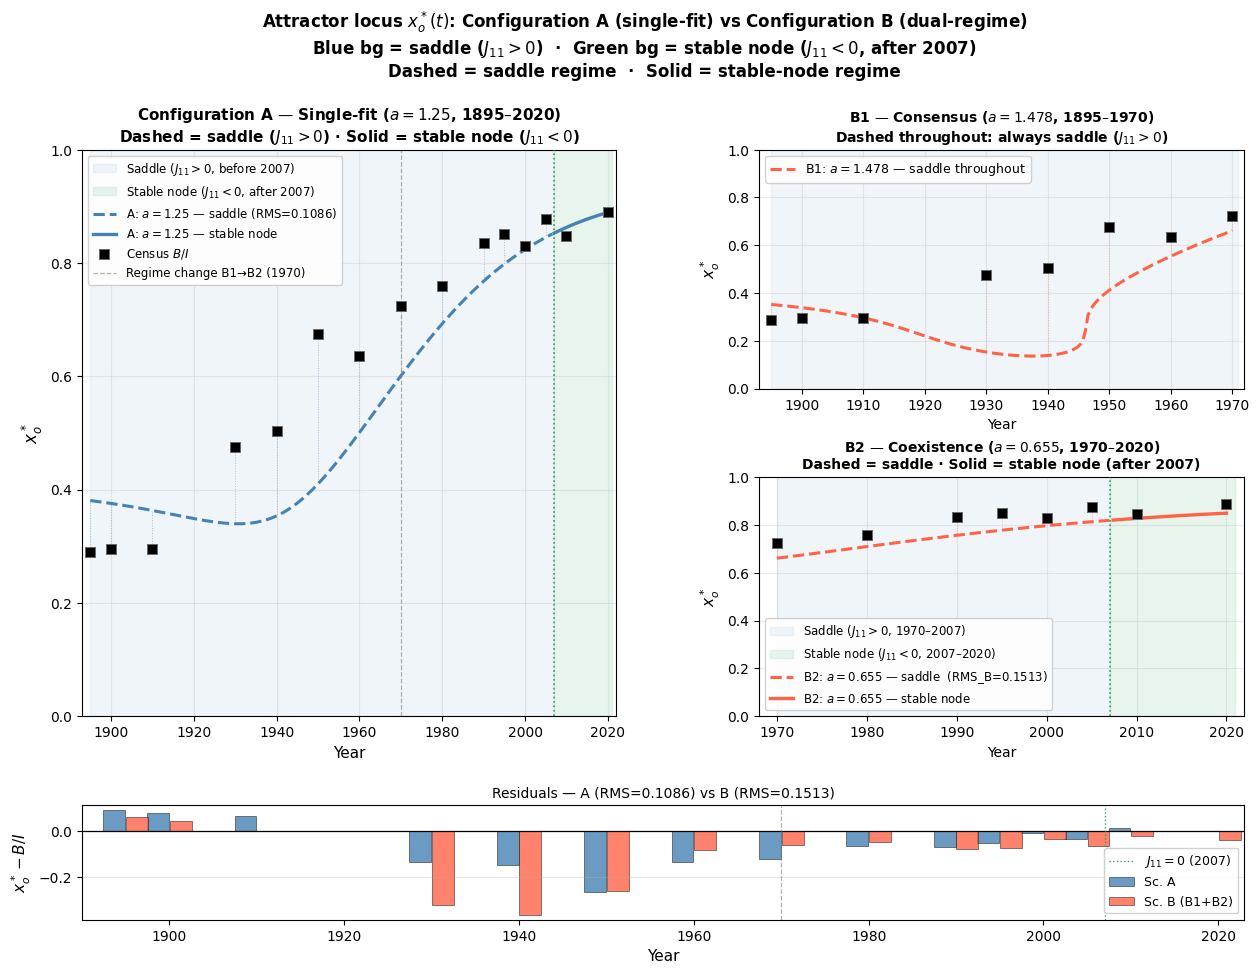

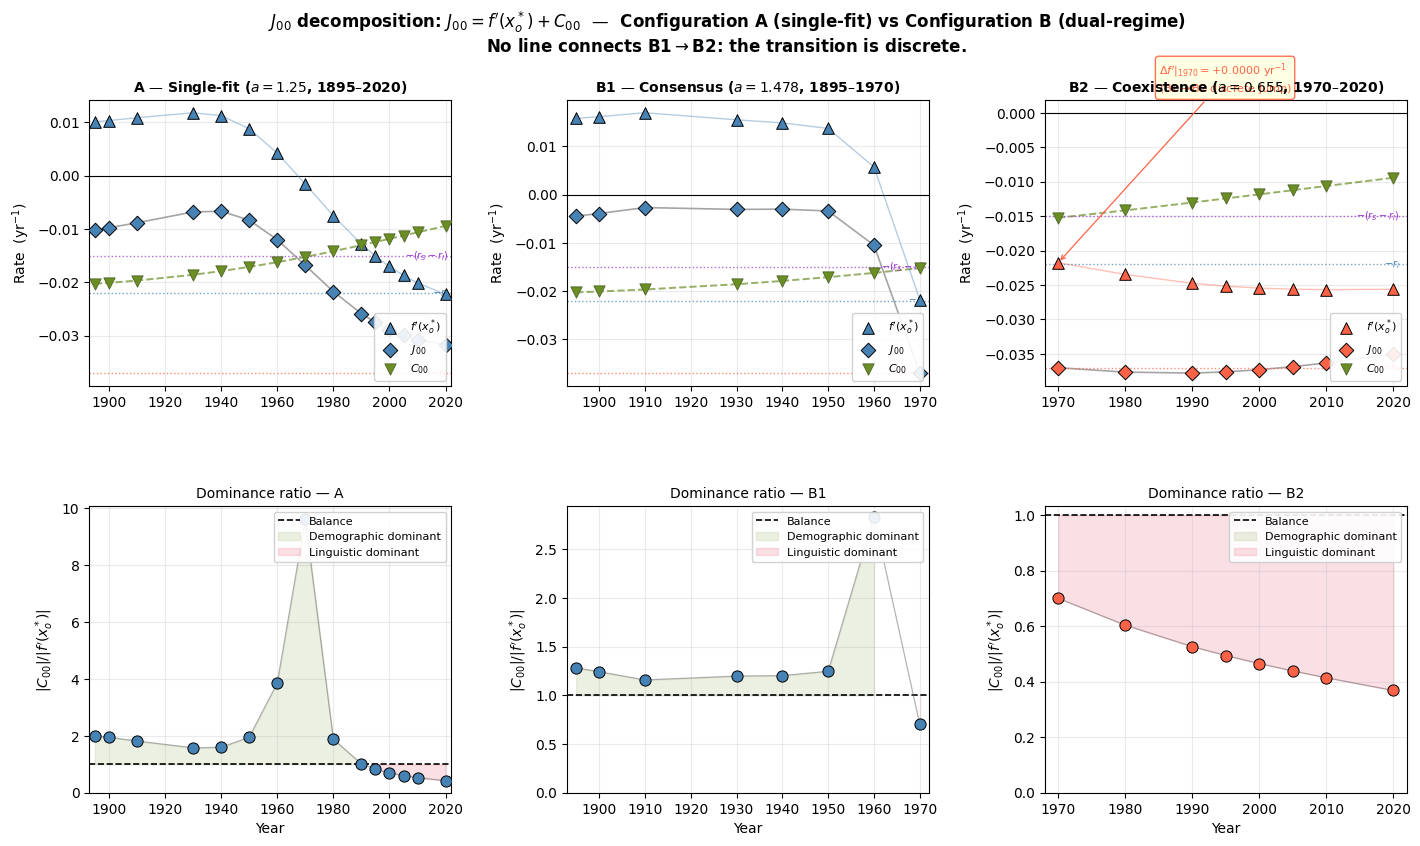

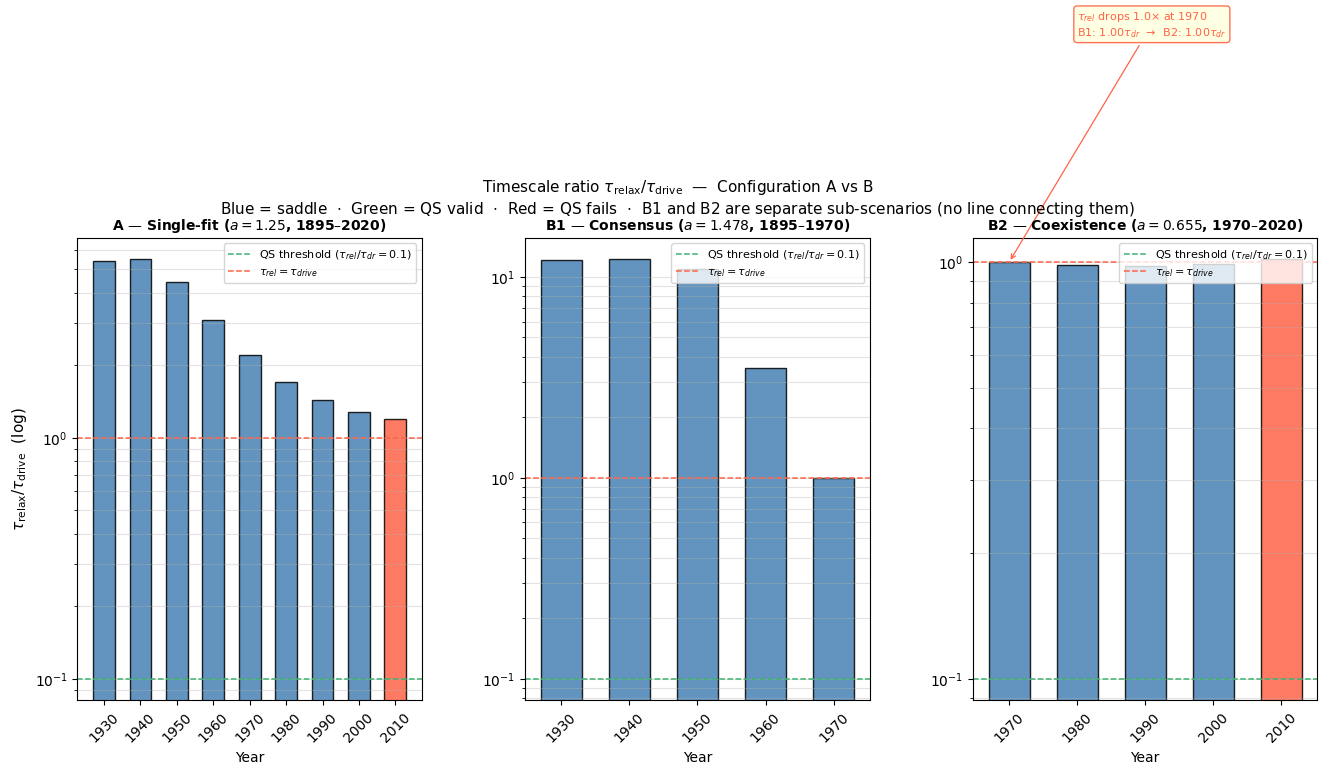

In [23]:
"""
24 Feb 2026
language_dynamics_extended_v5.py
==================================
Fixed and restructured version.  Two scenarios only.

PARAMETERS
----------
  S_O_CONS     = 0.0454   Consensus prestige (o→l)   — used ONLY 1895-1970
  S_L_CONS     = 0.00839  Consensus prestige (l→o)   — used ONLY 1895-1970
  A_CONS       = 1.478    Consensus exponent          — used ONLY 1895-1970

  S_O_COEX     = 0.047    Coexistence prestige (o→l) — used ONLY 1970-2020
  S_L_COEX     = 0.015    Coexistence prestige (l→o) — used ONLY 1970-2020
  A_COEX       = 0.6553   Coexistence exponent        — used ONLY 1970-2020

  S_O_CONS_ALL = 0.0349   Single-fit prestige (o→l)  — used 1895-2020
  S_L_CONS_ALL = 0.0055   Single-fit prestige (l→o)  — used 1895-2020
  A_CONS_ALL   = 1.25     Single-fit exponent         — used 1895-2020

SCENARIOS
---------
  Configuration A  (single-fit, no regime change)
      1895-2020: S_O_CONS_ALL, S_L_CONS_ALL, A_CONS_ALL
      One global fit from data; eigenvalue sign analysis from this.
      RMS = 0.109

  Configuration B  (dual-regime)
      1895-1970: S_O_CONS, S_L_CONS, A_CONS     (sub-scenario B1, Consensus)
      1970-2020: S_O_COEX, S_L_COEX, A_COEX     (sub-scenario B2, Coexistence)
      RMS = 0.151  (worse 1930-1940 due to a=1.478 low-attractor effect)

KEY FIX vs v4
-------------
v4 applied the Coexistence parameters to ALL years including pre-1970.
v5 applies regime-aware parameters everywhere via regime_params(t, scenario).

NOTE ON SCENARIO B PERFORMANCE
-------------------------------
Configuration B (a=1.478 in Consensus) fits worse than A at 1930-1940 because
with a=1.478 the ASM interior FP of f alone lies at x_f* ≈ 0.028 (much
closer to zero than with a=1.25, where x_f* ≈ 0.0006).  When m_si is still
moderate (≈5-6 at 1930-1940), g is not strong enough to overcome the stronger
downward pull of f, and the balance x_o* settles at 0.14-0.15 instead of
0.34-0.35.  The system recovers from 1960 as m_si grows.
The eigenvalue structure however is what matters physically: the sign analysis
(f' vs C00, dominance ratio) is the same qualitative story for both scenarios.
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import brentq, fsolve

# ===========================================================================
# 1. DATA
# ===========================================================================
data = {
    'Year':       [1895, 1900, 1910, 1930, 1940, 1950, 1960,
                   1970, 1980, 1990, 1995, 2000, 2005, 2010, 2020],
    'Spanish':    [3394259.0,  4054539.0,  10907376.0, 11624643.0, 14080954.0,
                   19272593.0, 25968301.0, 36946313.0, 51353211.0, 64104668.0,
                   74378670.0, 78381411.0, 83704299.0, 93203961.0, 108408500.0],
    'Indigenous': [1030670.0,  1144766.0,  1619825.0,  2370324.0,  2490909.0,
                   2447615.0,  3030254.0,  3111415.0,  5181038.0,  5282347.0,
                   5483555.0,  6044547.0,  6011202.0,  6695228.0,  7177185.0],
    'Bilingual':  [297977.0,   337528.0,   478232.0,   1126925.0,  1253891.0,
                   1652544.0,  1925299.0,  2251561.0,  3932514.0,  4411818.0,
                   4671553.0,  5022373.0,  5274418.0,  5676791.0,  6383553.0],
}
df            = pd.DataFrame(data)
base_year     = 1895
df['t']       = df['Year'] - base_year
df['x_o_obs'] = df['Bilingual'] / df['Indigenous']

# ===========================================================================
# 2. PARAMETERS
# ===========================================================================
# --- Demographic (shared) ---
N0_indigenous = 1012848;  K_indigenous = 12918933;  r_indigenous = 0.022
N0_spanish    = 3117878;  K_spanish    = 165995301; r_spanish    = 0.037

# --- Bilingual birth probability ---
A_p = 5.47;  nu = 0.271;  p_max = 0.97

# --- Configuration A: single fit, whole period ---
S_O_CONS_ALL = 0.0349;  S_L_CONS_ALL = 0.0055;  A_CONS_ALL = 1.25

# --- Configuration B: dual-regime ---
S_O_CONS = 0.0454;  S_L_CONS = 0.00839;  A_CONS = 1.478   # B1: 1895-1970
S_O_COEX = 0.047;   S_L_COEX = 0.015;   A_COEX = 0.6553  # B2: 1970-2020

T_REGIME_CHANGE = 75.0   # year 1970

TAU_DRIVE = 1.0 / r_spanish   # ≈ 27 yr

T_CROSS_I = brentq(
    lambda t: K_indigenous / (1 + ((K_indigenous - N0_indigenous) / N0_indigenous)
                               * np.exp(-r_indigenous * t)) - K_indigenous / 2,
    0, 300
)
YEAR_CROSS_I = base_year + T_CROSS_I

# Configuration registry
SCENARIOS = {
    'A': {
        'label': 'A: Single-fit (a=1.25, 1895–2020)',
        'color': 'steelblue', 'ls': '-',
        'cons': dict(s_o=S_O_CONS_ALL, s_l=S_L_CONS_ALL, a=A_CONS_ALL),
        'coex': dict(s_o=S_O_CONS_ALL, s_l=S_L_CONS_ALL, a=A_CONS_ALL),
        'dual': False,
    },
    'B': {
        'label': 'B: Dual-regime (B1: a=1.478 / B2: a=0.655)',
        'color': 'tomato', 'ls': '--',
        'cons': dict(s_o=S_O_CONS, s_l=S_L_CONS, a=A_CONS),
        'coex': dict(s_o=S_O_COEX, s_l=S_L_COEX, a=A_COEX),
        'dual': True,
    },
}


# ===========================================================================
# 3. REGIME SELECTOR
# ===========================================================================

def regime_params(t, scenario='A'):
    """
    Return (s_o, s_l, a, label) for the given scenario at time t.

    Parameters
    ----------
    t        : float  years since base_year (1895)
    scenario : str    'A' or 'B'
    """
    sc = SCENARIOS[scenario]
    if t < T_REGIME_CHANGE:
        p   = sc['cons']
        lbl = 'B1-Consensus' if sc['dual'] else 'A-Single'
    else:
        p   = sc['coex']
        lbl = 'B2-Coexistence' if sc['dual'] else 'A-Single'
    return p['s_o'], p['s_l'], p['a'], lbl


# ===========================================================================
# 4. CORE FUNCTIONS
# ===========================================================================

def logistic_function(t, K, r, N0):
    return K / (1 + ((K - N0) / N0) * np.exp(-r * t))


def m_si(S, I):
    return np.where(I > 0, S / I, np.inf)


def p_o_func(m):
    return p_max / (1 + A_p * np.exp(-nu * m))


def f_func(x_o, s_o, s_l, a):
    """ASM prestige term."""
    if np.ndim(x_o) == 0:
        if x_o <= 0 or x_o >= 1:
            return 0.0
        with np.errstate(invalid='ignore', divide='ignore'):
            return s_o * (x_o**a) * (1 - x_o) - s_l * ((1 - x_o)**a) * x_o
    else:
        x_o = np.asarray(x_o, dtype=float)
        result = np.zeros_like(x_o)
        mask = (x_o > 0) & (x_o < 1)
        with np.errstate(invalid='ignore', divide='ignore'):
            xm = x_o[mask]
            result[mask] = s_o*(xm**a)*(1-xm) - s_l*((1-xm)**a)*xm
        return result


def g_func(x_o, p, m, I):
    """
    Natural increment (demographic) term.

    x_o^† — the zero of g alone
    ----------------------------
    x_o^† = p_o * [1 - (1 - p_o/p_max) * ν * m_si]

    This is the demographic *baseline* bilingualism: what bilingualism would
    be if prestige dynamics (f) were absent.  In practice x_o^† ≪ x_o* because
    f amplifies bilingualism far above this baseline.

    Example (year 1970, Configuration B):
      x_o^† ≈ 0.186   x_o* ≈ 0.662   Δ ≈ 0.476  (prestige amplification)

    The gap Δ = x_o* − x_o^† shrinks slowly as m_si grows (≈ 0.28 by 2020).
    x_o^† is regime-independent (depends only on m_si, A_p, ν, p_max).
    """
    bracket = p - x_o - p*(1 - p/p_max)*nu*m
    return bracket * r_indigenous * (1 - I/K_indigenous)


def rhs_scalar(x_o, p, m, I, s_o, s_l, a):
    return f_func(x_o, s_o, s_l, a) + g_func(x_o, p, m, I)


def dxo_dt(x_o, I, S, s_o, s_l, a):
    m = float(m_si(S, I))
    p = float(p_o_func(m))
    return f_func(x_o, s_o, s_l, a) + g_func(x_o, p, m, I)


def dI_dt(I):
    return r_indigenous * I * (1 - I / K_indigenous)


# ===========================================================================
# 5. FIXED-POINT FINDER
# ===========================================================================

def find_fixed_points(t, scenario='A', n_scan=2000):
    """Find all zeros of dx_o/dt = 0 at time t for the given scenario."""
    s_o, s_l, a, _ = regime_params(t, scenario)
    I_t = logistic_function(t, K_indigenous, r_indigenous, N0_indigenous)
    S_t = logistic_function(t, K_spanish,    r_spanish,    N0_spanish)
    m_t = float(m_si(S_t, I_t))
    p_t = float(p_o_func(m_t))

    xs   = np.linspace(0.01, 0.99, n_scan)
    vals = np.array([rhs_scalar(x, p_t, m_t, I_t, s_o, s_l, a) for x in xs])
    sc   = np.where(np.diff(np.sign(vals)))[0]

    roots = []
    for idx in sc:
        try:
            xr = brentq(
                lambda x: rhs_scalar(x, p_t, m_t, I_t, s_o, s_l, a),
                xs[idx], xs[idx+1], xtol=1e-10
            )
            roots.append((xr, I_t, S_t, p_t, s_o, s_l, a))
        except Exception:
            mid = 0.5*(xs[idx]+xs[idx+1])
            sol = fsolve(
                lambda x: rhs_scalar(x[0], p_t, m_t, I_t, s_o, s_l, a),
                [mid], full_output=True
            )
            if sol[2] == 1 and 0 < sol[0][0] < 1:
                roots.append((sol[0][0], I_t, S_t, p_t, s_o, s_l, a))
    return roots


# ===========================================================================
# 6. JACOBIAN AND STABILITY
# ===========================================================================

def calculate_jacobian(x_o, I, S, p, s_o, s_l, a):
    """Upper-triangular 2×2 Jacobian. Eigenvalues = J[0,0], J[1,1]."""
    m   = S / I
    eps = 1e-6
    xp  = min(x_o + eps, 0.999);  xm = max(x_o - eps, 0.001)
    J00 = (rhs_scalar(xp, p, m, I, s_o, s_l, a)
          -rhs_scalar(xm, p, m, I, s_o, s_l, a)) / (xp - xm)
    h   = p*(1 - nu*(S/I)) + (nu/p_max)*(S/I)*p**2 - x_o
    J01 = (-h*(r_indigenous/K_indigenous)
           + r_indigenous*(1 - I/K_indigenous)
           * nu**2*(S**2/I**3)*p*(1 - p/p_max)*(1 - 2*p/p_max))
    J11 = r_indigenous*(1 - 2*I/K_indigenous)
    return np.array([[J00, J01], [0.0, J11]])


def analyze_stability(fixed_points):
    """Classify each fixed point.  Input: list of (x_o,I,S,p,s_o,s_l,a) tuples."""
    results = []
    for x_o, I, S, p, s_o, s_l, a in fixed_points:
        J    = calculate_jacobian(x_o, I, S, p, s_o, s_l, a)
        eigs = np.linalg.eigvals(J)
        re   = np.real(eigs)
        fs   = bool(np.all(re < 0))
        sad  = bool(np.any(re < 0) and np.any(re > 0))
        ex   = re[np.argmin(np.abs(re - J[0, 0]))]
        eI   = re[np.argmin(np.abs(re - J[1, 1]))]
        results.append({
            'x_o': x_o, 'I': I, 'S': S, 'p': p,
            's_o': s_o, 's_l': s_l, 'a': a,
            'fully_stable': fs, 'saddle': sad,
            'eigenvalues': eigs, 'eig_x': ex, 'eig_I': eI,
            'tau_x': 1.0/abs(ex) if ex < 0 else np.inf,
        })
    return results


# ===========================================================================
# 7. STABLE FIXED POINT SERIES
# ===========================================================================

def stable_fp_series(t_arr, scenario='A'):
    """Return x_o*(t) for each t in t_arr; nan where no stable FP exists."""
    result = np.full(len(t_arr), np.nan)
    for k, t in enumerate(t_arr):
        s_o, s_l, a, _ = regime_params(t, scenario)
        I_t = logistic_function(t, K_indigenous, r_indigenous, N0_indigenous)
        S_t = logistic_function(t, K_spanish,    r_spanish,    N0_spanish)
        m_t = float(m_si(S_t, I_t))
        p_t = float(p_o_func(m_t))
        xs   = np.linspace(0.01, 0.99, 3000)
        vals = np.array([rhs_scalar(x, p_t, m_t, I_t, s_o, s_l, a) for x in xs])
        sc   = np.where(np.diff(np.sign(vals)))[0]
        for idx in sc:
            try:
                xr = brentq(
                    lambda x: rhs_scalar(x, p_t, m_t, I_t, s_o, s_l, a),
                    xs[idx], xs[idx+1], xtol=1e-10
                )
                sl = (rhs_scalar(xr+1e-5, p_t, m_t, I_t, s_o, s_l, a)
                     -rhs_scalar(xr-1e-5, p_t, m_t, I_t, s_o, s_l, a)) / 2e-5
                if sl < 0:
                    result[k] = xr
                    break
            except Exception:
                pass
    return result


# ===========================================================================
# 8. COMPARISON TABLE WITH J00 DECOMPOSITION
# ===========================================================================

def print_comparison_table():
    """
    Print x_o*, residuals, and J00 decomposition at all census years
    for both scenarios.

    J00 decomposition
    -----------------
    J00 = f'(x_o*) + C00    where C00 = -r_I*(1 - I/K_I)

    Configuration A (a=1.25 throughout):
      f'(x_o*) > 0 for 1895-1960 (repelling — C00 sole stabiliser)
      f'(x_o*) changes sign after the demographic transition (~1970-1980)

    Configuration B1 (a=1.478, 1895-1970):
      f'(x_o*) > 0 throughout Consensus  (C00 sole stabiliser)
    Configuration B2 (a=0.6553, 1970-2020):
      f'(x_o*) < 0 throughout Coexistence (linguistic dominant)
    """
    rows = []
    for yr, xo_obs in zip(df['Year'], df['x_o_obs']):
        t_val = yr - base_year
        row   = {'year': yr, 'xo_obs': xo_obs}
        for sc_key in ('A', 'B'):
            s_o, s_l, a, rlbl = regime_params(t_val, sc_key)
            I_t = logistic_function(t_val, K_indigenous, r_indigenous, N0_indigenous)
            S_t = logistic_function(t_val, K_spanish,    r_spanish,    N0_spanish)
            m_t = float(m_si(S_t, I_t))
            p_t = float(p_o_func(m_t))
            xs   = np.linspace(0.01, 0.99, 4000)
            vals = np.array([rhs_scalar(x, p_t, m_t, I_t, s_o, s_l, a) for x in xs])
            sc_a = np.where(np.diff(np.sign(vals)))[0]
            xr   = np.nan
            for idx in sc_a:
                try:
                    root = brentq(
                        lambda x: rhs_scalar(x, p_t, m_t, I_t, s_o, s_l, a),
                        xs[idx], xs[idx+1]
                    )
                    sl = (rhs_scalar(root+1e-6, p_t, m_t, I_t, s_o, s_l, a)
                         -rhs_scalar(root-1e-6, p_t, m_t, I_t, s_o, s_l, a)) / 2e-6
                    if sl < 0:
                        xr = root; break
                except Exception:
                    pass
            row[f'xo_{sc_key}']    = xr
            row[f'res_{sc_key}']   = xr - xo_obs if np.isfinite(xr) else np.nan
            row[f'regime_{sc_key}']= rlbl
            # J00 decomposition for each scenario
            if np.isfinite(xr):
                eps = 1e-6
                fp  = (f_func(min(xr+eps,0.9999), s_o, s_l, a)
                      -f_func(max(xr-eps,0.0001), s_o, s_l, a)) / (2*eps)
                c00 = -r_indigenous*(1 - I_t/K_indigenous)
                row[f'fp_{sc_key}']    = fp
                row[f'c00_{sc_key}']   = c00
                row[f'ratio_{sc_key}'] = abs(c00)/abs(fp) if abs(fp) > 1e-15 else np.inf
                row[f'j00_{sc_key}']   = fp + c00
            else:
                for k in (f'fp_{sc_key}', f'c00_{sc_key}', f'ratio_{sc_key}', f'j00_{sc_key}'):
                    row[k] = np.nan
        rows.append(row)

    # --- Print ---
    print("\n" + "="*130)
    print("TWO-SCENARIO COMPARISON  |  J00 decomposition for each scenario")
    print("  A: Single-fit a=1.25 (1895-2020)  |  B: Dual-regime B1(a=1.478) + B2(a=0.655)")
    print("="*130)
    hdr_A = "  xo*(A)   res(A)        regime_A    f'(A)       C00   |C|/|f'|    J00(A)"
    hdr_B = "  xo*(B)   res(B)        regime_B    f'(B)    J00(B)"
    print(f"{'Year':>4}  {'obs':>6}" + hdr_A + "  ||" + hdr_B)
    print("  " + "-"*128)
    for row in rows:
        flag = "←" if row['year'] in (1960, 1970) else ""
        print(
            f"{row['year']:>4}  {row['xo_obs']:>6.4f}  "
            f"{row['xo_A']:>7.4f}  {row['res_A']:>+7.4f}  {row['regime_A']:>14}  "
            f"{row['fp_A']:>+8.4f}  {row['c00_A']:>+8.4f}  "
            f"{row['ratio_A']:>9.3f}  {row['j00_A']:>+8.4f}  ||  "
            f"{row['xo_B']:>7.4f}  {row['res_B']:>+7.4f}  {row['regime_B']:>14}  "
            f"{row['fp_B']:>+8.4f}  {row['j00_B']:>+8.4f}  {flag}"
        )
    print("\n  RMS residuals:")
    # Full scenarios
    for sc_key in ('A', 'B'):
        sq = [row[f'res_{sc_key}']**2
              for row in rows if np.isfinite(row.get(f'res_{sc_key}', np.nan))]
        print(f"    Configuration {sc_key} (full):  RMS = {np.sqrt(np.mean(sq)):.5f}")
    # B split by sub-scenario
    sq_B1 = [row['res_B']**2 for row in rows
             if row['year'] <= 1970 and np.isfinite(row.get('res_B', np.nan))]
    sq_B2 = [row['res_B']**2 for row in rows
             if row['year'] >= 1970 and np.isfinite(row.get('res_B', np.nan))]
    sq_A1 = [row['res_A']**2 for row in rows
             if row['year'] <= 1970 and np.isfinite(row.get('res_A', np.nan))]
    sq_A2 = [row['res_A']**2 for row in rows
             if row['year'] >= 1970 and np.isfinite(row.get('res_A', np.nan))]
    print(f"    Configuration A  1895-1970:  RMS = {np.sqrt(np.mean(sq_A1)):.5f}")
    print(f"    Configuration A  1970-2020:  RMS = {np.sqrt(np.mean(sq_A2)):.5f}")
    print(f"    Configuration B1 1895-1970:  RMS = {np.sqrt(np.mean(sq_B1)):.5f}")
    print(f"    Configuration B2 1970-2020:  RMS = {np.sqrt(np.mean(sq_B2)):.5f}")

    return pd.DataFrame(rows)


# ===========================================================================
# 9. ATTRACTOR LOCUS COMPARISON
# ===========================================================================

def plot_attractor_locus_comparison(n_t=300, plot_dir='plots/lang_dyn_ext/'):
    """
    Three-panel layout:
      Top-left  (wide): Configuration A — single-fit, 1895-2020
      Top-right-top:    Configuration B1 — Consensus, 1895-1970
      Top-right-bottom: Configuration B2 — Coexistence, 1970-2020
      Bottom (full width): residuals A vs B at census years
    """
    # Time arrays per scenario / sub-scenario
    t_A   = np.linspace(0,   125, n_t)        # 1895-2020
    t_B1  = np.linspace(0,   75,  int(n_t*0.6))  # 1895-1970
    t_B2  = np.linspace(75,  125, int(n_t*0.4))  # 1970-2020

    yr_A  = base_year + t_A
    yr_B1 = base_year + t_B1
    yr_B2 = base_year + t_B2

    print("\n  Computing attractor loci...")
    xA  = stable_fp_series(t_A,  'A');  print("    A done.")
    xB1 = stable_fp_series(t_B1, 'B');  print("    B1 done.")
    xB2 = stable_fp_series(t_B2, 'B');  print("    B2 done.")

    obs_yr = df['Year'].values
    xo_obs = df['x_o_obs'].values

    # RMS
    rmsA = np.sqrt(np.mean((np.interp(obs_yr-base_year, t_A, xA) - xo_obs)**2))
    # B: stitch B1 and B2 at census years
    xB_at_census = np.array([
        float(np.interp(yr-base_year, t_B1, xB1)) if yr <= 1970
        else float(np.interp(yr-base_year, t_B2, xB2))
        for yr in obs_yr
    ])
    resA = np.interp(obs_yr-base_year, t_A, xA) - xo_obs
    resB = xB_at_census - xo_obs
    rmsB = np.sqrt(np.mean(resB**2))

    # --- Layout: 2 rows, left column spans both rows (A), right has B1/B2 ---
    fig = plt.figure(figsize=(15, 10))
    gs  = fig.add_gridspec(3, 2,
                           height_ratios=[2.5, 2.5, 1.2],
                           width_ratios=[1.1, 1],
                           hspace=0.45, wspace=0.28)

    ax_A   = fig.add_subplot(gs[0:2, 0])   # left, spans top 2 rows
    ax_B1  = fig.add_subplot(gs[0,   1])   # top-right
    ax_B2  = fig.add_subplot(gs[1,   1])   # bottom-right
    ax_res = fig.add_subplot(gs[2,   :])   # residuals, full width

    # ── Configuration A ──────────────────────────────────────────────
    # Background: light blue (saddle, J11>0) up to YEAR_CROSS_I,
    #             light green (stable node, J11<0) after
    ax_A.axvspan(1895,          YEAR_CROSS_I, alpha=0.08, color='steelblue', zorder=0,
                 label=f'Saddle ($J_{{11}}>0$, before {YEAR_CROSS_I:.0f})')
    ax_A.axvspan(YEAR_CROSS_I, 2021,          alpha=0.12, color='mediumseagreen', zorder=0,
                 label=f'Stable node ($J_{{11}}<0$, after {YEAR_CROSS_I:.0f})')
    ax_A.axvline(YEAR_CROSS_I, color='seagreen', lw=1.2, ls=':', alpha=0.9, zorder=3)
    # Line: dashed before YEAR_CROSS_I, solid after
    mask_A_saddle = yr_A <= YEAR_CROSS_I
    mask_A_stable = yr_A >= YEAR_CROSS_I
    ax_A.plot(yr_A[mask_A_saddle], xA[mask_A_saddle],
              color='steelblue', lw=2.2, ls='--',
              label=f'A: $a=1.25$ — saddle (RMS={rmsA:.4f})')
    ax_A.plot(yr_A[mask_A_stable], xA[mask_A_stable],
              color='steelblue', lw=2.4, ls='-',
              label='A: $a=1.25$ — stable node')
    ax_A.scatter(obs_yr, xo_obs, color='k', marker='s', s=55, zorder=6,
                 edgecolors='dimgray', lw=0.7, label='Census $B/I$')
    for yr, xo in zip(obs_yr, xo_obs):
        xm = float(np.interp(yr-base_year, t_A, xA))
        if np.isfinite(xm):
            ax_A.plot([yr,yr], [xo,xm], color='steelblue', lw=0.7, ls=':', alpha=0.45)
    ax_A.axvline(1970, color='grey', lw=0.9, ls='--', alpha=0.6,
                 label='Regime change B1→B2 (1970)')
    ax_A.set_xlim(1893, 2022); ax_A.set_ylim(0, 1)
    ax_A.set_xlabel('Year', fontsize=11); ax_A.set_ylabel(r'$x_o^*$', fontsize=12)
    ax_A.set_title(
        'Configuration A — Single-fit ($a=1.25$, 1895–2020)\n'
        r'Dashed = saddle ($J_{11}>0$) · Solid = stable node ($J_{11}<0$)',
        fontsize=11, fontweight='bold')
    ax_A.legend(fontsize=8.5, loc='upper left', framealpha=0.9)
    ax_A.grid(alpha=0.25)

    # ── Configuration B1 (1895-1970) — always saddle, background unchanged ───
    ax_B1.axvspan(1895, 1971, alpha=0.08, color='steelblue', zorder=0)
    ax_B1.plot(yr_B1, xB1, color='tomato', lw=2.2, ls='--',
               label='B1: $a=1.478$ — saddle throughout')
    obs_mask_pre  = obs_yr <= 1970
    ax_B1.scatter(obs_yr[obs_mask_pre], xo_obs[obs_mask_pre],
                  color='k', marker='s', s=50, zorder=6, edgecolors='dimgray', lw=0.7)
    for yr, xo in zip(obs_yr[obs_mask_pre], xo_obs[obs_mask_pre]):
        xm = float(np.interp(yr-base_year, t_B1, xB1))
        if np.isfinite(xm):
            ax_B1.plot([yr,yr], [xo,xm], color='tomato', lw=0.7, ls=':', alpha=0.45)
    ax_B1.set_xlim(1893, 1972); ax_B1.set_ylim(0, 1)
    ax_B1.set_xlabel('Year', fontsize=10)
    ax_B1.set_ylabel(r'$x_o^*$', fontsize=11)
    ax_B1.set_title('B1 — Consensus ($a=1.478$, 1895–1970)\n'
                    r'Dashed throughout: always saddle ($J_{11}>0$)',
                    fontsize=10, fontweight='bold')
    ax_B1.legend(fontsize=9, loc='upper left', framealpha=0.9)
    ax_B1.grid(alpha=0.25)

    # ── Configuration B2 (1970-2020) ──────────────────────────────────
    # Background: light blue (saddle, J11>0) 1970-YEAR_CROSS_I,
    #             light green (stable node, J11<0) after
    ax_B2.axvspan(1970,          YEAR_CROSS_I, alpha=0.08, color='steelblue', zorder=0,
                  label=f'Saddle ($J_{{11}}>0$, 1970–{YEAR_CROSS_I:.0f})')
    ax_B2.axvspan(YEAR_CROSS_I, 2021,          alpha=0.12, color='mediumseagreen', zorder=0,
                  label=f'Stable node ($J_{{11}}<0$, {YEAR_CROSS_I:.0f}–2020)')
    ax_B2.axvline(YEAR_CROSS_I, color='seagreen', lw=1.2, ls=':', alpha=0.9, zorder=3)
    # Line: dashed before YEAR_CROSS_I, solid after
    mask_B2_saddle = yr_B2 <= YEAR_CROSS_I
    mask_B2_stable = yr_B2 >= YEAR_CROSS_I
    ax_B2.plot(yr_B2[mask_B2_saddle], xB2[mask_B2_saddle],
               color='tomato', lw=2.2, ls='--',
               label=f'B2: $a=0.655$ — saddle  (RMS_B={rmsB:.4f})')
    ax_B2.plot(yr_B2[mask_B2_stable], xB2[mask_B2_stable],
               color='tomato', lw=2.4, ls='-',
               label='B2: $a=0.655$ — stable node')
    obs_mask_post = obs_yr >= 1970
    ax_B2.scatter(obs_yr[obs_mask_post], xo_obs[obs_mask_post],
                  color='k', marker='s', s=50, zorder=6, edgecolors='dimgray', lw=0.7)
    for yr, xo in zip(obs_yr[obs_mask_post], xo_obs[obs_mask_post]):
        xm = float(np.interp(yr-base_year, t_B2, xB2))
        if np.isfinite(xm):
            ax_B2.plot([yr,yr], [xo,xm], color='tomato', lw=0.7, ls=':', alpha=0.45)
    ax_B2.set_xlim(1968, 2022); ax_B2.set_ylim(0, 1)
    ax_B2.set_xlabel('Year', fontsize=10)
    ax_B2.set_ylabel(r'$x_o^*$', fontsize=11)
    ax_B2.set_title('B2 — Coexistence ($a=0.655$, 1970–2020)\n'
                    r'Dashed = saddle · Solid = stable node (after 2007)',
                    fontsize=10, fontweight='bold')
    ax_B2.legend(fontsize=8.5, loc='lower left', framealpha=0.9)
    ax_B2.grid(alpha=0.25)

    # ── Residuals (full width) ───────────────────────────────────
    width = 2.5
    ax_res.bar(obs_yr - 1.3, resA, width=width, color='steelblue',
               edgecolor='k', lw=0.4, alpha=0.80, label='Sc. A')
    ax_res.bar(obs_yr + 1.3, resB, width=width, color='tomato',
               edgecolor='k', lw=0.4, alpha=0.80, label='Sc. B (B1+B2)')
    ax_res.axhline(0, color='k', lw=0.9)
    ax_res.axvline(1970, color='grey', lw=0.9, ls='--', alpha=0.6)
    ax_res.axvline(YEAR_CROSS_I, color='seagreen', lw=1.0, ls=':', alpha=0.85,
                   label=f'$J_{{11}}=0$ ({YEAR_CROSS_I:.0f})')
    ax_res.set_xlim(1890, 2023)
    ax_res.set_xlabel('Year', fontsize=11)
    ax_res.set_ylabel(r'$x_o^* - B/I$', fontsize=11)
    ax_res.set_title(f'Residuals — A (RMS={rmsA:.4f}) vs B (RMS={rmsB:.4f})', fontsize=10)
    ax_res.legend(fontsize=9, loc='lower right', framealpha=0.9)
    ax_res.grid(axis='y', alpha=0.3)

    fig.suptitle(
        r'Attractor locus $x_o^*(t)$: Configuration A (single-fit) vs Configuration B (dual-regime)'
        '\n'
        r'Blue bg = saddle ($J_{11}>0$)  ·  Green bg = stable node ($J_{11}<0$, after 2007)'
        '\n'
        r'Dashed = saddle regime  ·  Solid = stable-node regime',
        fontsize=12, fontweight='bold', y=1.02)

    fname = f"{plot_dir}attractor_locus_comparison.jpg"
    fig.savefig(fname, dpi=300, bbox_inches='tight')
    print(f"  Saved: {fname}")
    return fig


# ===========================================================================
# 10. J00 DECOMPOSITION — BOTH SCENARIOS
# ===========================================================================

def plot_j00_decomposition(plot_dir='plots/lang_dyn_ext/'):
    """
    J00 decomposition with scenario-correct time spans.

    Layout: 3 columns x 2 rows
      Col 0: Configuration A (1895-2020, full)
      Col 1: Configuration B1 (1895-1970 only)
      Col 2: Configuration B2 (1970-2020 only)
      Row 0: f'(x_o*), C00, J00
      Row 1: dominance ratio |C00|/|f'|

    Lines within a scenario are continuous; NO line connects B1 to B2
    (the transition is discrete, not a smooth interpolation).
    """
    census_years = df['Year'].values
    yrs_pre  = census_years[census_years <= 1970]
    yrs_post = census_years[census_years >= 1970]

    def _compute(yrs, sc_key):
        fp_v=[]; c00_v=[]; j00_v=[]; rat_v=[]
        for yr in yrs:
            t_val = yr - base_year
            s_o, s_l, a, _ = regime_params(t_val, sc_key)
            I_t = logistic_function(t_val, K_indigenous, r_indigenous, N0_indigenous)
            S_t = logistic_function(t_val, K_spanish,    r_spanish,    N0_spanish)
            m_t = float(m_si(S_t, I_t)); p_t = float(p_o_func(m_t))
            xs   = np.linspace(0.01, 0.99, 4000)
            vals = np.array([rhs_scalar(x, p_t, m_t, I_t, s_o, s_l, a) for x in xs])
            sc_a = np.where(np.diff(np.sign(vals)))[0]
            xr   = np.nan
            for idx in sc_a:
                try:
                    root = brentq(lambda x: rhs_scalar(x, p_t, m_t, I_t, s_o, s_l, a),
                                  xs[idx], xs[idx+1])
                    sl = (rhs_scalar(root+1e-6, p_t, m_t, I_t, s_o, s_l, a)
                         -rhs_scalar(root-1e-6, p_t, m_t, I_t, s_o, s_l, a)) / 2e-6
                    if sl < 0: xr = root; break
                except: pass
            if np.isfinite(xr):
                eps = 1e-6
                fp  = (f_func(min(xr+eps,0.9999), s_o, s_l, a)
                      -f_func(max(xr-eps,0.0001), s_o, s_l, a)) / (2*eps)
                c00 = -r_indigenous*(1 - I_t/K_indigenous)
                fp_v.append(fp); c00_v.append(c00)
                j00_v.append(fp+c00)
                rat_v.append(abs(c00)/abs(fp) if abs(fp) > 1e-15 else np.inf)
            else:
                for lst in (fp_v, c00_v, j00_v, rat_v): lst.append(np.nan)
        return dict(fp=np.array(fp_v), c00=np.array(c00_v),
                    j00=np.array(j00_v), rat=np.array(rat_v))

    rA   = _compute(census_years, 'A')
    rB1  = _compute(yrs_pre,      'B')
    rB2  = _compute(yrs_post,     'B')

    # Reference lines
    ref_lines = [
        (-r_indigenous,             'steelblue',  r'$-r_I$'),
        (-r_spanish,                'tomato',      r'$-r_S$'),
        (-(r_spanish-r_indigenous), 'darkorchid', r'$-(r_S-r_I)$'),
    ]

    def _panel_top(ax, yrs, r, clr, xlim, title):
        ax.axhline(0, color='k', lw=0.8)
        ax.scatter(yrs, r['fp'],  color=clr, marker='^', s=70, edgecolors='k',
                   lw=0.7, zorder=5, label=r"$f'(x_o^*)$")
        ax.scatter(yrs, r['j00'], color=clr, marker='D', s=55, edgecolors='k',
                   lw=0.7, zorder=5, label=r"$J_{00}$")
        ax.scatter(yrs, r['c00'], color='olivedrab', marker='v', s=65,
                   edgecolors='darkolivegreen', lw=0.7, zorder=5, label=r'$C_{00}$')
        ax.plot(yrs, r['c00'], color='olivedrab', lw=1.4, ls='--', alpha=0.7)
        ax.plot(yrs, r['j00'], color='dimgray',   lw=1.2, ls='-',  alpha=0.6)
        ax.plot(yrs, r['fp'],  color=clr,         lw=1.0, ls='-',  alpha=0.4)
        for rate, rclr, lbl in ref_lines:
            ax.axhline(rate, color=rclr, lw=1.0, ls=':', alpha=0.75)
            ax.text(xlim[1]-1, rate, lbl, fontsize=7, color=rclr, va='center', ha='right')
        ax.set_xlim(*xlim); ax.grid(alpha=0.25)
        ax.set_ylabel(r'Rate  (yr$^{-1}$)', fontsize=10)
        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.legend(fontsize=8, loc='lower right', framealpha=0.9)

    def _panel_bot(ax, yrs, r, clr, xlim, title):
        ax.axhline(1.0, color='k', lw=1.2, ls='--', label='Balance')
        ax.scatter(yrs, r['rat'], color=clr, marker='o', s=65,
                   edgecolors='k', lw=0.7, zorder=5)
        ax.plot(yrs, r['rat'], color='dimgray', lw=0.9, ls='-', alpha=0.5)
        ax.fill_between(yrs, r['rat'], 1.0, where=r['rat'] > 1.0,
                        alpha=0.13, color='olivedrab', label='Demographic dominant')
        ax.fill_between(yrs, r['rat'], 1.0, where=r['rat'] < 1.0,
                        alpha=0.13, color='crimson',   label='Linguistic dominant')
        ax.set_xlim(*xlim); ax.grid(alpha=0.25)
        ax.set_ylim(bottom=0)
        ax.set_ylabel(r"$|C_{00}|/|f'(x_o^*)|$", fontsize=10)
        ax.set_xlabel('Year', fontsize=10)
        ax.set_title(title, fontsize=10)
        ax.legend(fontsize=8, loc='upper right', framealpha=0.9)

    fig, axes = plt.subplots(2, 3, figsize=(17, 9),
                             gridspec_kw={'hspace': 0.42, 'wspace': 0.32})
    (ax_tA, ax_tB1, ax_tB2), (ax_bA, ax_bB1, ax_bB2) = axes

    _panel_top(ax_tA,  census_years, rA,  'steelblue', (1893, 2022),
               'A — Single-fit ($a=1.25$, 1895–2020)')
    _panel_top(ax_tB1, yrs_pre,      rB1, 'steelblue', (1893, 1972),
               'B1 — Consensus ($a=1.478$, 1895–1970)')
    _panel_top(ax_tB2, yrs_post,     rB2, 'tomato',    (1968, 2022),
               'B2 — Coexistence ($a=0.655$, 1970–2020)')

    _panel_bot(ax_bA,  census_years, rA,  'steelblue', (1893, 2022),
               'Dominance ratio — A')
    _panel_bot(ax_bB1, yrs_pre,      rB1, 'steelblue', (1893, 1972),
               'Dominance ratio — B1')
    _panel_bot(ax_bB2, yrs_post,     rB2, 'tomato',    (1968, 2022),
               'Dominance ratio — B2')

    # Annotate the discrete jump B1→B2 on B2 top panel
    fp_at_1970_B1 = rB1['fp'][yrs_pre == 1970][0]
    fp_at_1970_B2 = rB2['fp'][yrs_post == 1970][0]
    delta_fp = fp_at_1970_B2 - fp_at_1970_B1
    ax_tB2.annotate(
        fr"$\Delta f'|_{{1970}} = {delta_fp:+.4f}$ yr$^{{-1}}$" '\n'
        r"(B1$\to$B2 discrete jump)",
        xy=(1970, fp_at_1970_B2), xytext=(1985, 0.003),
        fontsize=8, color='tomato',
        arrowprops=dict(arrowstyle='->', color='tomato', lw=0.9),
        bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', ec='tomato', alpha=0.9)
    )

    fig.suptitle(
        r'$J_{00}$ decomposition: $J_{00} = f^\prime(x_o^*) + C_{00}$'
        '  —  Configuration A (single-fit) vs Configuration B (dual-regime)\n'
        r'No line connects B1$\to$B2: the transition is discrete.',
        fontsize=12, fontweight='bold'
    )

    fname = f"{plot_dir}j00_decomposition_AB.jpg"
    fig.savefig(fname, dpi=300, bbox_inches='tight')
    print(f"  Saved: {fname}")
    return fig


# ===========================================================================
# 11. TIMESCALE CHECK
# ===========================================================================

def run_timescale_analysis(time_points, plot_dir='plots/lang_dyn_ext/'):
    print("\n" + "="*72)
    print("TIMESCALE CHECK — Configuration A and B")
    print(f"  tau_drive = 1/r_S = {TAU_DRIVE:.2f} yr   J11 sign change at {YEAR_CROSS_I:.0f}")
    print("="*72)

    records = []
    for sc_key in ('A', 'B'):
        sc = SCENARIOS[sc_key]
        print(f"\n  --- Configuration {sc_key}: {sc['label']} ---")
        print(f"  {'Year':>4}  {'Regime':>16}  {'x_o*':>6}  "
              f"{'tau_relax':>9}  {'ratio':>7}  {'Status'}")
        print("  " + "-"*65)
        for t in time_points:
            yr  = int(base_year + t)
            fps = find_fixed_points(t, sc_key)
            sta = analyze_stability(fps)
            _, _, _, rlbl = regime_params(t, sc_key)
            for d in sta:
                ratio  = d['tau_x'] / TAU_DRIVE
                status = ("SADDLE"    if d['saddle']       else
                          "STABLE"    if d['fully_stable'] else "UNSTABLE")
                flag   = ("QS ok"     if ratio < 0.1  else
                          "marginal"  if ratio < 1.0  else "QS fails")
                tau_s  = f"{d['tau_x']:9.2f}" if np.isfinite(d['tau_x']) else "      inf"
                print(f"  {yr:>4}  {rlbl:>16}  {d['x_o']:>6.4f}  "
                      f"{tau_s}  {ratio:>7.4f}  {status}  {flag}")
                records.append({'sc': sc_key, 'year': yr, 't': t,
                                'regime': rlbl, 'x_o': d['x_o'],
                                'tau_x': d['tau_x'], 'ratio': ratio,
                                'stability': status})

    df_ts = pd.DataFrame(records)

    # --- Layout: 1 row, 3 panels: A (full) | B1 (pre-1970) | B2 (post-1970) ---
    fig, (ax_A, ax_B1, ax_B2) = plt.subplots(1, 3, figsize=(16, 6),
                                              gridspec_kw={'wspace': 0.30})

    def _bar_panel(ax, sub, xlim_yr, title, show_B_sep=False):
        """Draw a bar panel. sub is filtered df_ts rows."""
        for _, row in sub.iterrows():
            if not np.isfinite(row['ratio']): continue
            clr = ('steelblue'      if row['stability'] == 'SADDLE'
                   else 'mediumseagreen' if row['ratio'] < 0.1 else 'tomato')
            ax.bar(str(int(row['year'])), row['ratio'],
                   color=clr, edgecolor='k', alpha=0.85, width=0.6)
        ax.axhline(0.1, color='mediumseagreen', ls='--', lw=1.1,
                   label=r'QS threshold ($\tau_{rel}/\tau_{dr}=0.1$)')
        ax.axhline(1.0, color='tomato',         ls='--', lw=1.1,
                   label=r'$\tau_{rel} = \tau_{drive}$')
        ax.set_yscale('log')
        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.set_xlabel('Year', fontsize=10)
        ax.tick_params(axis='x', rotation=45)
        ax.grid(axis='y', alpha=0.35, which='both')
        ax.legend(fontsize=8, loc='upper right')

    sub_A  = df_ts[df_ts['sc'] == 'A']
    sub_B  = df_ts[df_ts['sc'] == 'B']
    sub_B1 = sub_B[sub_B['year'] <= 1970]
    sub_B2 = sub_B[sub_B['year'] >= 1970]

    _bar_panel(ax_A,  sub_A,  None, 'A — Single-fit ($a=1.25$, 1895–2020)')
    _bar_panel(ax_B1, sub_B1, None, 'B1 — Consensus ($a=1.478$, 1895–1970)')
    _bar_panel(ax_B2, sub_B2, None, 'B2 — Coexistence ($a=0.655$, 1970–2020)')

    ax_A.set_ylabel(r'$\tau_{\rm relax}/\tau_{\rm drive}$  (log)', fontsize=11)

    # Annotate τ jump at 1970 on B2 panel
    tau_1970_B1 = sub_B1[sub_B1['year'] == 1970]['tau_x'].values
    tau_1970_B2 = sub_B2[sub_B2['year'] == 1970]['tau_x'].values
    if len(tau_1970_B1) and len(tau_1970_B2):
        ratio_B1 = float(tau_1970_B1[0]) / TAU_DRIVE
        ratio_B2 = float(tau_1970_B2[0]) / TAU_DRIVE
        ax_B2.annotate(
            fr'$\tau_{{rel}}$ drops {ratio_B1/ratio_B2:.1f}$\times$ at 1970' '\n'
            fr'B1: {ratio_B1:.2f}$\tau_{{dr}}$  →  B2: {ratio_B2:.2f}$\tau_{{dr}}$',
            xy=(0, ratio_B2), xytext=(1, 3.5),
            fontsize=8, color='tomato',
            arrowprops=dict(arrowstyle='->', color='tomato', lw=0.9),
            bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', ec='tomato', alpha=0.9)
        )

    fig.suptitle(
        r'Timescale ratio $\tau_{\rm relax}/\tau_{\rm drive}$'
        '  —  Configuration A vs B\n'
        'Blue = saddle  '
        r'$\cdot$  '
        'Green = QS valid  '
        r'$\cdot$  '
        'Red = QS fails  '
        r'$\cdot$  '
        'B1 and B2 are separate sub-scenarios (no line connecting them)',
        fontsize=11
    )
    plt.tight_layout()
    fname = f"{plot_dir}timescale_comparison.jpg"
    fig.savefig(fname, dpi=300, bbox_inches='tight')
    print(f"\n  Saved: {fname}")
    return df_ts, fig


# ===========================================================================
# 12. VECTOR FIELD SNAPSHOTS (optional, for phase portraits)
# ===========================================================================

def compute_vector_field(t_star, scenario='A', nx=30, nI=30, I_margin=0.5):
    s_o, s_l, a, _ = regime_params(t_star, scenario)
    I_t = logistic_function(t_star, K_indigenous, r_indigenous, N0_indigenous)
    S_t = logistic_function(t_star, K_spanish,    r_spanish,    N0_spanish)
    m_t = float(m_si(S_t, I_t)); p_t = float(p_o_func(m_t))

    x_arr = np.linspace(0.02, 0.98, nx)
    I_lo  = max(I_t*(1 - I_margin), 0.01*K_indigenous)
    I_hi  = min(I_t*(1 + I_margin), 0.999*K_indigenous)
    I_arr = np.linspace(I_lo, I_hi, nI)
    X, IG = np.meshgrid(x_arr, I_arr)
    U = np.array([[dxo_dt(X[i,j], IG[i,j], S_t, s_o, s_l, a) for j in range(nx)] for i in range(nI)])
    V = np.array([[dI_dt(IG[i,j]) for j in range(nx)] for i in range(nI)])

    mag   = np.sqrt(U**2 + V**2)
    mag95 = np.percentile(mag[mag > 0], 95) if np.any(mag > 0) else 1.0
    return dict(X=X, IG=IG, U=U/mag95, V=V/mag95, magnitude=mag,
                S_t=S_t, I_t=I_t, p_t=p_t, m_t=m_t,
                x_arr=x_arr, I_arr=I_arr, s_o=s_o, s_l=s_l, a=a)


def compute_nullcline_dxo(t_star, I_arr, scenario='A', n_scan=2000):
    s_o, s_l, a, _ = regime_params(t_star, scenario)
    S_t = logistic_function(t_star, K_spanish, r_spanish, N0_spanish)
    nullcline = []
    for I_val in I_arr:
        if I_val <= 0: continue
        m_val = float(m_si(S_t, I_val)); p_val = float(p_o_func(m_val))
        xs    = np.linspace(0.02, 0.98, n_scan)
        vals  = np.array([rhs_scalar(x, p_val, m_val, I_val, s_o, s_l, a) for x in xs])
        for idx in np.where(np.diff(np.sign(vals)))[0]:
            try:
                xn = brentq(lambda x: rhs_scalar(x, p_val, m_val, I_val, s_o, s_l, a),
                            xs[idx], xs[idx+1], xtol=1e-8)
                nullcline.append((xn, I_val))
            except: pass
    return nullcline


# ===========================================================================
# 13. ENTRY POINT
# ===========================================================================

def main():
    plot_dir = 'plots/lang_dyn_ext/'
    os.makedirs(plot_dir, exist_ok=True)

    print("="*72)
    print(" language_dynamics_extended_v5.py")
    print("  Configuration A: single-fit a=1.25 (1895-2020)")
    print("  Configuration B: dual-regime B1(a=1.478 / 1895-1970) + B2(a=0.655 / 1970-2020)")
    print(f"  J11 sign change at year {YEAR_CROSS_I:.0f}")
    print("="*72)

    # 1. Comparison table + J00 decomposition
    df_table = print_comparison_table()

    # 2. Attractor locus
    fig_locus = plot_attractor_locus_comparison(plot_dir=plot_dir)
    # 3. J00 decomposition side-by-side
    fig_j00 = plot_j00_decomposition(plot_dir=plot_dir)

    # 4. Timescale check
    time_points = [35.0, 45.0, 55.0, 65.0, 75.0, 85.0, 95.0, 105.0, 115.0]
    df_ts, fig_ts = run_timescale_analysis(time_points, plot_dir=plot_dir)

    print("\nAll figures saved to", plot_dir)
    plt.show()
    return df_table, df_ts


if __name__ == "__main__":
    df_table, df_ts = main()